# PA005 - High Value Customer Identification (Insiders)

# 0 - IMPORTS </font>

In [54]:
# Data Maniputalion and Data Analysis
import re
import pandas                as pd
import seaborn               as sns
import numpy                 as np

from matplotlib              import pyplot          as plt

# ML Algorithms
import umap.umap_            as umap

from sklearn.manifold        import TSNE
from sklearn                 import preprocessing as pp
from sklearn                 import ensemble      as en
from sklearn                 import decomposition as dd
from sklearn                 import cluster       as cc
from sklearn                 import metrics       as mt
from sklearn                 import ensemble      as en

# 1 - DATA LOADING

## 1.1 - LOADING DATA

In [2]:
df = pd.read_csv("../data/raw/Ecommerce.csv")

# drop extra column
df = df.drop( columns=['Unnamed: 8'], axis=1)

## 1.2 - DATA DESCRIPTIVE

### 1.2.1 - RENAME COLUMNS

In [3]:
df1 = df.copy()

In [4]:
cols_new = ['invoice_no','stock_code','description','quantity','invoice_date','unit_price','customer_id','country']
df1.columns = cols_new

### 1.2.2 - DATA DIMENSIONS

In [5]:
print('Number of columns: {}'.format( df1.shape[1] ) )
print('Number of rows: {}'.format( df1.shape[0] ) )

Number of columns: 8
Number of rows: 541909


### 1.2.3 - DATA TYPES

In [6]:
df1.dtypes

invoice_no       object
stock_code       object
description      object
quantity          int64
invoice_date     object
unit_price      float64
customer_id     float64
country          object
dtype: object

### 1.2.4 - CHECK NA VALUES

In [7]:
df1.isna().sum()

invoice_no           0
stock_code           0
description       1454
quantity             0
invoice_date         0
unit_price           0
customer_id     135080
country              0
dtype: int64

### 1.2.5 - REPLACE NAN VALUES

In [8]:
# The datas containing missing customer_id are being moved to a new dataset
df_missing = df1.loc[df1['customer_id'].isna(), :]
df_not_missing = df1.loc[~df1['customer_id'].isna(),:]

In [9]:
# Identifying which are the invoices without customer id
missing_invoice = df_missing['invoice_no'].drop_duplicates().tolist()

In [10]:
# Create reference and creating a customer_id for the invoices.
df_backup = pd.DataFrame( df_missing['invoice_no'].drop_duplicates() ) # creating a copy from the dataset that contains missing invoice_no
df_backup['customer_id'] = np.arange( 19000, 19000+len( df_backup), 1) # creating a invoice_no for the datas without this information

# Merge orginal with reference dataframe
df1 = pd.merge( df1, df_backup, on='invoice_no', how='left')

# Coalese
df1['customer_id'] = df1['customer_id_x'].combine_first( df1['customer_id_y'] ) # combine the dataset from the "main" column that contains the original values with the new column that contains the created value for invoice_no 

# Drop extra columns
df1 = df1.drop( columns=['customer_id_x','customer_id_y'], axis=1 )

### 1.2.6 - CHANGE DTYPES

In [11]:
#df1.dtypes

In [12]:
df1[ 'invoice_date'] = pd.to_datetime( df1['invoice_date'], format='%d-%b-%y') # changing the data on the column invoice data to match the correct data type

df1['customer_id'] = df1['customer_id'].astype( int ) # changing the data on the column customer id data to match the correct data type

### 1.2.7 - DESCRIPTIVE STATISTICS

In [13]:
num_attributes = df1.select_dtypes( include=['int64', 'float64'] ) # add numerical datas into a new data frame
cat_attributes = df1.select_dtypes( exclude=['int64', 'float64', 'datetime64[ns]'] ) # add categorical datas into a new data frame

### 1.2.7.1 - Numerical Attributes

In [14]:
# Central Tendency
ct1 = pd.DataFrame( num_attributes.apply( np.mean ) ).T
ct2 = pd.DataFrame( num_attributes.apply( np.median ) ).T

# Dispersion - 
d1 = pd.DataFrame( num_attributes.apply( np.std ) ).T
d2 = pd.DataFrame( num_attributes.apply( np.min ) ).T
d3 = pd.DataFrame( num_attributes.apply( np.max ) ).T
d4 = pd.DataFrame( num_attributes.apply( lambda x: x.max() - x.min() ) ).T
d5 = pd.DataFrame( num_attributes.apply( lambda x: x.skew() ) ).T
d6 = pd.DataFrame( num_attributes.apply( lambda x: x.kurtosis() ) ).T

# Concatenate
m = pd.concat( [d2, d3, d4, ct1, ct2, d1, d5, d6]).T.reset_index()
m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis']
m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,quantity,-80995.00,80995.0,161990.00,9.552250,3.00,218.080957,-0.264076,119769.160031
1,unit_price,-11062.06,38970.0,50032.06,4.611114,2.08,96.759764,186.506972,59005.719097


##### Stock Code

In [15]:
# # Problem: There are codes on stock_code that are composed of letters and we do not know the meaning
# df1.loc[df1['stock_code'].apply( lambda x: bool( re.search('^[a-zA-Z]+$', x ) ) ), 'stock_code'].unique()

# # SOLUTION: Remove sotck_code composed of letters or codes as per ['POST', 'D', 'M', 'PADS', 'DOT', 'CRUK']

##### Description

In [16]:
# ACTION: REMOVE THIS COLUMN FROM THE DATASET AS THIS DO NOT HELPS TO GENERATE A CLUSTER
# df1.head()

##### Country

In [17]:
# df1['country'].unique()

In [18]:
# # Qty sales made per country
# df1['country'].value_counts( normalize=True )

# 2 - DATA FILTERING

On this project, the step **DATA FILTERING** will be done earlier as some features are been calculated from the dataset and are combined with that dataset later on, and it's our duty to make sure that we are keeping our data clean and without errors.

In [19]:
df2 = df1.copy()

In [20]:
# --- NUMERICAL ATTRIBUTES ---
df2 = df2.loc[df2['unit_price'] >= 0.04, :]

# --- CATEGORICAL ATTRIBUTES ---
df2 = df2[~df2['stock_code'].isin( ['POST', 'D', 'DOT', 'M', 'S', 'AMAZONFEE', 'm', 'DCGSSBOY', 'DCGSSGIRL', 'PADS', 'B', 'CRUK'] ) ]

# Description
df2 = df2.drop( columns='description', axis=1)

# MAP
df2 = df2[~df2['country']. isin( ['European Community','Unspecified'] ) ]

# Bad Users
df2 = df2[~df2['customer_id'].isin( [16446] ) ]

# Quantity
df2_returns = df2.loc[df1['quantity'] < 0, :]   # Dataset containing only returns
df2_purchases = df2.loc[df1['quantity'] >=0, :] # Dataset containing only sells

# 3 - FATURE ENGINEERING

In [21]:
df3 = df2.copy()

In [ ]:
# Features
# Moving Average
# Qty of purchases by month, before 26th and after 26th

In [22]:
# data reference
df_ref = df2.drop( ['invoice_no','stock_code','quantity','invoice_date','unit_price','country'],axis=1).drop_duplicates(ignore_index=True)

## 3.1 - Gross Revenue

In [23]:
# Gross Revenue
df2_purchases.loc[:, 'gross_revenue'] = df2_purchases.loc[:, 'quantity'] * df2_purchases.loc[:, 'unit_price']

# Monetary
df_monetary = df2_purchases.loc[:, ['customer_id', 'gross_revenue']].groupby('customer_id').sum().reset_index()
df_ref = pd.merge( df_ref, df_monetary, on='customer_id', how='left')

df_ref.isna().sum()

C:\Users\perot\AppData\Local\Temp\ipykernel_25816\1624802604.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_purchases.loc[:, 'gross_revenue'] = df2_purchases.loc[:, 'quantity'] * df2_purchases.loc[:, 'unit_price']


customer_id       0
gross_revenue    91
dtype: int64

## 3.2 - Recency - Day from last purchase

In [24]:
# Recency
df_recency = df2_purchases.loc[:, ['customer_id', 'invoice_date']].groupby('customer_id').max().reset_index()
df_recency['recency_days'] = (df2_purchases['invoice_date'].max() - df_recency['invoice_date']).dt.days
df_recency = df_recency[['customer_id','recency_days']].copy()
df_ref = pd.merge( df_ref, df_recency, on='customer_id', how='left')

df_ref.isna().sum()

customer_id       0
gross_revenue    91
recency_days     91
dtype: int64

## 3.4 Qty of products purchased

In [25]:
# Number of products
df_freqp = ( df2_purchases.loc[:,['customer_id', 'quantity']].groupby('customer_id')
                                                           .sum().reset_index()
                                                           .rename( columns={'quantity':'qty_of_products'}) )

df_ref = pd.merge(df_ref, df_freqp, on='customer_id', how='left')
df_ref.isna().sum()

customer_id         0
gross_revenue      91
recency_days       91
qty_of_products    91
dtype: int64

## 3.8 - Frequency of Purchases

In [26]:
# Mean of times that 

In [27]:
df2_max = df2_purchases[['customer_id','invoice_date']].drop_duplicates().groupby('customer_id').max().reset_index() # finding the last date of purchase per customer
df2_min = df2_purchases[['customer_id','invoice_date']].drop_duplicates().groupby('customer_id').min().reset_index() # finding the last date of purchase per customer

df_aux = ( df2_purchases[['customer_id','invoice_no','invoice_date']].drop_duplicates()
                                                           .groupby('customer_id')
                                                           .agg( max_ =('invoice_date', 'max'),
                                                                 min_ =('invoice_date', 'min'),
                                                                 days_=('invoice_date', lambda x:( (x.max() - x.min() ).days)+1),
                                                                 buy_ =('invoice_no', 'count'))).reset_index()

# Frequency
df_aux['frequency'] = df_aux[['buy_', 'days_']].apply( lambda x: x['buy_'] / x['days_'] if x['days_'] != 0 else 0, axis=1 )

# Merge
df_ref = pd.merge(df_ref, df_aux[['customer_id','frequency']], on='customer_id', how='left')

df_ref.isna().sum()

customer_id         0
gross_revenue      91
recency_days       91
qty_of_products    91
frequency          91
dtype: int64

## 3.9 - Returns

In [28]:
# Number of returns
df_returns = df2_returns[['customer_id','quantity']].groupby('customer_id').sum().reset_index().rename( columns={'quantity':'qty_returns'})
df_returns['qty_returns'] = df_returns['qty_returns'] * -1

df_ref = pd.merge( df_ref, df_returns, on='customer_id', how='left')
df_ref.loc[df_ref['qty_returns'].isna(), 'qty_returns'] = 0

df_ref.isna().sum()

customer_id         0
gross_revenue      91
recency_days       91
qty_of_products    91
frequency          91
qty_returns         0
dtype: int64

## 4.3 - Space of Study

In [42]:
df4 = df_ref.dropna()

In [43]:
df4.shape

(5695, 6)

In [45]:
# Original Dataset
#df43 = df4.drop( columns=['customer_id'], axis=1 ).copy()

# Selected Dataset
cols_selected = ['customer_id', 'gross_revenue', 'recency_days', 'qty_of_products', 'frequency' , 'qty_returns']
df43 = df4[ cols_selected ]

In [46]:
# Standardization
mms = pp.MinMaxScaler()

# Transformer
df43['gross_revenue']     = mms.fit_transform( df43[['gross_revenue']])
df43['recency_days']      = mms.fit_transform( df43[['recency_days']])
df43['qty_of_products']   = mms.fit_transform( df43[['qty_of_products']])
df43['frequency']         = mms.fit_transform( df43[['frequency']])
df43['qty_returns']       = mms.fit_transform( df43[['qty_returns']])

X = df43.copy()

### 4.3.4 - Tree-Based Embedding

In [47]:
# Training dataset
X = df43.drop( columns=['customer_id','gross_revenue'], axis=1 ).copy()
y = df43['gross_revenue']

# model definition
rf_model = en.RandomForestRegressor( n_estimators=100, random_state=42 )

# model trainig
rf_model.fit(X, y)

# Leaf
df_leaf = pd.DataFrame( rf_model.apply( X ) ) # here i am selecting the datas from the leaf of tree

C:\Users\perot\anaconda3\envs\pa_clustering\lib\site-packages\sklearn\manifold\_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


<AxesSubplot:xlabel='embedding_x', ylabel='embedding_y'>

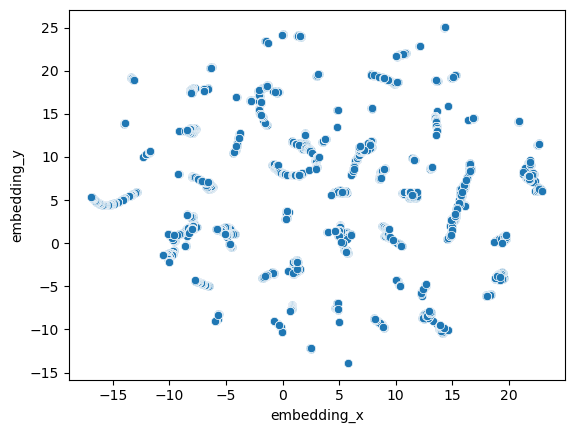

In [48]:
# UMAP 
reducer = umap.UMAP( random_state = 42 )
embedding = reducer.fit_transform( df_leaf )

# Embedding 
df_tree = pd.DataFrame()
df_tree['embedding_x'] = embedding[:, 0]
df_tree['embedding_y'] = embedding[:, 1]

# 5 - DATA PREPARATION

In [49]:
df5 = df_tree.copy()

# 6 - FEATURE SELECTION

In [50]:
df6 = df5.copy()

# 7 - FINE TUNING

In [51]:
X = df_tree.copy()

In [52]:
X.head()

,embedding_x,embedding_y
0,12.726829,-4.719460
1,13.805153,-9.658109
2,16.288080,7.500883
3,1.097511,-3.423558
4,-4.029222,16.895412


# 8 - MACHINE LEARNING TRAINING

## 8.1 - KMeans

In [73]:
# Model Definition
k = 11
kmeans = cc.KMeans( init='random', n_clusters=k, n_init=300, max_iter=300, random_state=42 )

# Model Trainin
kmeans.fit( X )

# Model Prediction
labels = kmeans.labels_

## 8.2 - Cluster Validation

In [74]:
# Silhouette Score
print( 'SS Score: {}'.format( mt.silhouette_score( X, labels, metric='euclidean' ) ) )

SS Score: 0.4685884714126587


## 9.4 - Cluster Profile

In [75]:
df94 = df4[ cols_selected ].copy()
df94['cluster'] = labels
df94.head()

,customer_id,gross_revenue,recency_days,qty_of_products,frequency,qty_returns,cluster
0,17850,5391.21,372.0,1733.0,17.000000,40.0,1
1,13047,3232.59,56.0,1390.0,0.028302,35.0,1
2,12583,6705.38,2.0,5028.0,0.040323,50.0,0
3,13748,948.25,95.0,439.0,0.017921,0.0,8
4,15100,876.00,333.0,80.0,0.073171,22.0,6


In [76]:
# Number of Customer
df_cluster = df94[['customer_id', 'cluster']].groupby('cluster').count().reset_index()
df_cluster['perc_customer'] = 100*( df_cluster['customer_id'] / df_cluster['customer_id'].sum() )

# Avg Gross Revenue
df_avg_gross_revenue = df94[['gross_revenue', 'cluster']].groupby('cluster').mean().reset_index()
df_cluster = pd.merge( df_cluster, df_avg_gross_revenue, how='inner', on='cluster')

# Avg Recency Days
df_avg_recency_days = df94[['recency_days', 'cluster']].groupby('cluster').mean().reset_index()
df_cluster = pd.merge( df_cluster, df_avg_recency_days, how='inner', on='cluster')

# Avg Qty Products
df_qty_product = df94[['qty_of_products', 'cluster']].groupby('cluster').mean().reset_index()
df_cluster = pd.merge( df_cluster, df_qty_product, how='inner', on='cluster')

# Avg Frequency
df_freq = df94[['frequency', 'cluster']].groupby('cluster').mean().reset_index()
df_cluster = pd.merge( df_cluster, df_freq, how='inner', on='cluster')

# Avg Returns
df_ret = df94[['qty_returns', 'cluster']].groupby('cluster').mean().reset_index()
df_cluster = pd.merge( df_cluster, df_ret, how='inner', on='cluster')
df_cluster

,cluster,customer_id,perc_customer,gross_revenue,recency_days,qty_of_products,frequency,qty_returns
0,0,650,11.413521,4646.971846,67.363077,2738.456923,0.304586,42.756923
1,1,455,7.989464,2728.460132,59.951648,1511.942857,0.245011,18.410989
2,2,433,7.603161,277.815289,195.937644,91.764434,0.785038,1.771363
3,3,730,12.818262,81.811397,188.832877,22.068493,0.974978,0.542466
4,4,495,8.691835,6171.693313,131.573737,3439.917172,0.747630,247.872727
5,5,309,5.425812,1797.191262,43.854369,1054.271845,0.029683,17.967638
6,6,473,8.305531,516.236702,98.847780,242.084567,0.343540,3.443975
7,7,897,15.750658,441.103701,131.903010,207.370123,0.717112,2.537347
8,8,502,8.814750,1307.688705,116.942231,527.336653,0.558106,7.517928
9,9,333,5.847234,1350.814384,52.396396,758.201201,0.035936,11.426426


# 11 - DEPLOY